# Specificity content of the MEROPS serum panel

## Scope

The window score $S^{M}_{\pi,b}$ of the serum proteolysis calibration is read
off the MEROPS specificity matrices of dataset 35. This notebook measures
whether those matrices carry specificity information and whether the score they
produce is reproducible. It does not fit any model and does not use any kinetic
measurement.

Event geometry is determined in
`0_02_serum_peptidase_identity.ipynb`; the kinetic sources are audited in
`0_09` to `0_03`; the decisions drawn from all of them are combined in `0_13`.

## Questions

1. How is cleavage evidence distributed across the panel entries?
2. How deep is each individual subsite, as opposed to the pooled count reported
   per peptidase?
3. Which subsites depart from the residue composition of the substrate pool by
   more than sampling noise produces?
4. How reproducible is a per-protease score under the uncertainty of the
   underlying counts?
5. How many distinct specificity profiles does the panel contain?

## Inputs and outputs

Inputs: `data/merops/35_human_serum/` (counts, log-probabilities, `codes.json`),
`data/reference/human_proteome/composition.json`, and DBAASP sequences from
`data/peptides_data/peptides_mic/peptides_apex.csv` as a scoring probe.

Output: `results/0_01_merops_matrices.csv`.

Execution requires the reference composition, which is produced by
`assets/scripts/downloads/serum_proteolysis_calibration/download_human_proteome.py`.

In [1]:
import sys
from pathlib import Path

# The shared module sits one directory above the notebook; locating it by content
# keeps the notebooks working if the analysis directory is renamed or renumbered.
_cwd = Path.cwd().resolve()
_notebooks = next(p for p in [_cwd, *_cwd.parents] if (p / "_analysis_common.py").is_file())
sys.path.insert(0, str(_notebooks))

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr

import _analysis_common as common
from pep_compass.optimization.components.helpers.proteolysis import (
    MEROPS_AMINO_ACIDS,
    MEROPS_SUBSITES,
    CleavagePotential,
    ProteasePanel,
    bootstrap_specificity_matrices,
    cluster_profiles,
    expected_null_information_content,
    information_content_excess,
    load_amino_acid_background,
    load_panel_metadata,
    load_protease_panel,
    profile_similarity_matrix,
)

common.apply_style()

## Parameters

Every knob this notebook has is in the cell below: thresholds, filters, sample
sizes and seeds. Shared policy that several notebooks obey — the assay-condition
window, the minimum evidence per protease, the permutation count — lives in
`_analysis_common.py` and is imported rather than repeated, so a change there
reaches every notebook that does not override it here.

In [2]:
# Scoring probe and resampling budget.
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PROBE_PEPTIDES = 1000
N_BOOTSTRAP = 32
REDUNDANCY_THRESHOLD = 0.8
SEED = 20260920

# Reference residue distribution for every specificity metric in this notebook.
HUMAN_COMPOSITION = common.ROOT / "data" / "reference" / "human_proteome" / "composition.json"

In [3]:
if not HUMAN_COMPOSITION.is_file():
    raise FileNotFoundError(
        "Run assets/scripts/downloads/serum_proteolysis_calibration/download_human_proteome.py "
        "to produce the reference residue composition."
    )
human_background = load_amino_acid_background(HUMAN_COMPOSITION)  # (A,)

print(f"repository root: {common.ROOT}")
print(f"device: {DEVICE}")
print(f"reference composition: {HUMAN_COMPOSITION.relative_to(common.ROOT)}")
print(
    "most frequent residue: "
    f"{MEROPS_AMINO_ACIDS[int(np.argmax(human_background))]} "
    f"({human_background.max():.4f}); least frequent: "
    f"{MEROPS_AMINO_ACIDS[int(np.argmin(human_background))]} ({human_background.min():.4f})"
)

repository root: /home/max/repositories/pep-compass
device: cuda
reference composition: data/reference/human_proteome/composition.json
most frequent residue: L (0.0996); least frequent: W (0.0121)


In [4]:
counts_panel = load_protease_panel(
    common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="counts", device="cpu"
)
logprob_panel = load_protease_panel(
    common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT, kind="logprob", device=DEVICE
)
metadata = load_panel_metadata(common.SERUM_DATASET_ID, merops_root=common.MEROPS_ROOT)

counts = counts_panel.matrices.numpy().astype(np.float64)  # (N, P, A)
log_probabilities = logprob_panel.matrices.cpu().numpy().astype(np.float64)  # (N, P, A)
codes = list(counts_panel.codes)

panel = pd.DataFrame(metadata)[["code", "name", "n_cleavages", "serum_category"]]
assert list(panel["code"]) == codes, "codes.json order must match the matrix row order"

print(f"panel entries: {len(panel)} | matrices: {counts.shape}")
print(f"pooled cleavages: {int(panel['n_cleavages'].sum())}")

panel entries: 55 | matrices: (55, 8, 20)
pooled cleavages: 13121


## Distribution of cleavage evidence

`n_cleavages` is the number of substrate cleavages MEROPS records for a
peptidase code, pooled over all sequences assigned to that code. It bounds
every later diagnostic: a matrix estimated from one cleavage is a point mass,
not a preference.

In [5]:
coverage_thresholds = [1, 5, 10, 20, 30, 50, 100, 200, 500]
coverage = pd.DataFrame(
    {
        "min_cleavages": coverage_thresholds,
        "n_proteases": [int((panel["n_cleavages"] >= t).sum()) for t in coverage_thresholds],
    }
)
coverage["share_of_panel"] = (coverage["n_proteases"] / len(panel)).round(3)

print(panel["n_cleavages"].describe().round(1).to_string())
print()
print(coverage.to_string(index=False))

count      55.0
mean      238.6
std       626.7
min         1.0
25%         8.5
50%        20.0
75%       119.0
max      3417.0

 min_cleavages  n_proteases  share_of_panel
             1           55           1.000
             5           50           0.909
            10           38           0.691
            20           29           0.527
            30           25           0.455
            50           22           0.400
           100           16           0.291
           200            9           0.164
           500            4           0.073


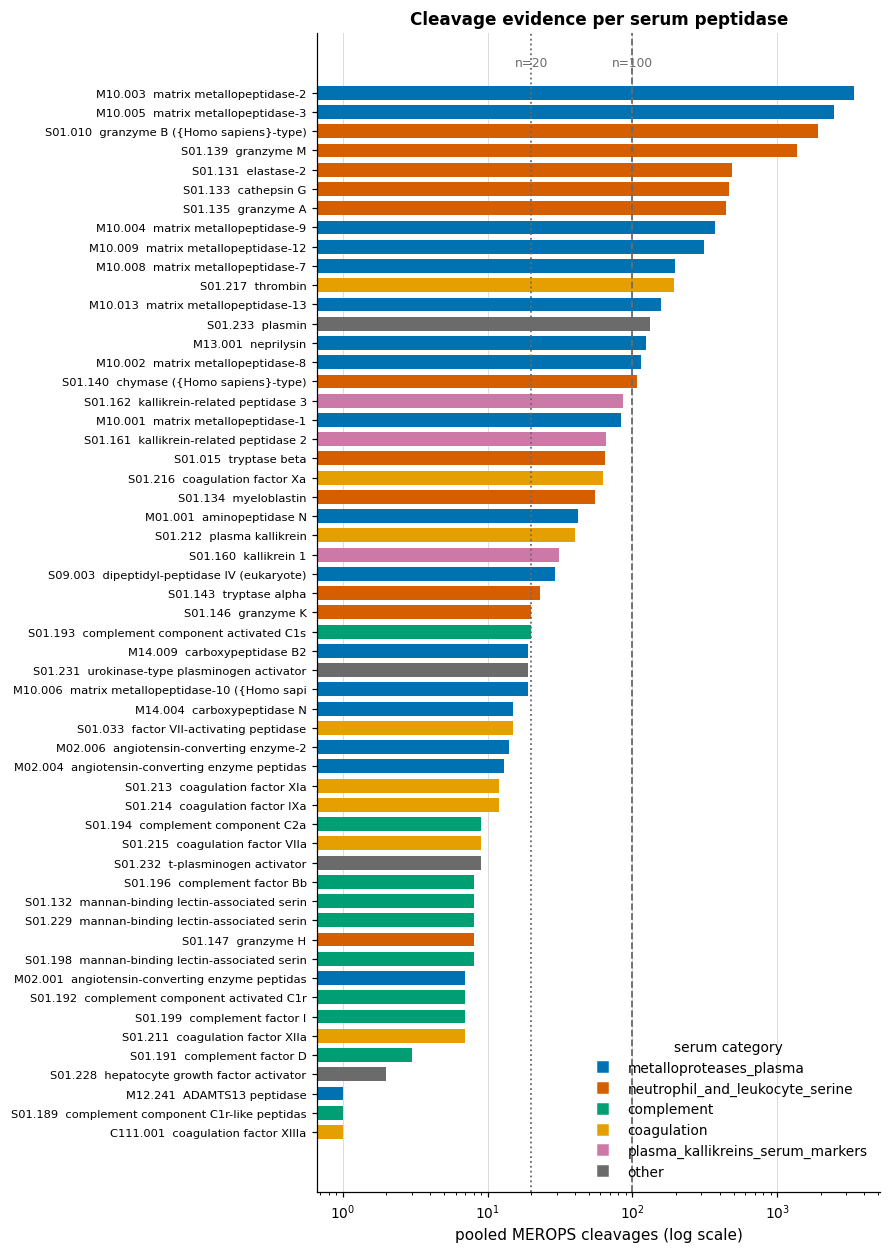

In [6]:
## Group the panel's serum categories into the fixed colour slots
category_sizes = panel["serum_category"].value_counts()
major_categories = list(category_sizes.index[: len(common.CATEGORICAL_COLORS) - 1])
category_color = {name: common.CATEGORICAL_COLORS[i] for i, name in enumerate(major_categories)}
panel["category_group"] = panel["serum_category"].where(
    panel["serum_category"].isin(major_categories), "other"
)
category_color["other"] = common.NEUTRAL

ordered = panel.sort_values("n_cleavages", ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(8.2, 11.5))
ax.barh(
    ordered.index,
    ordered["n_cleavages"],
    color=[category_color[group] for group in ordered["category_group"]],
    height=0.72,
)
ax.set_yticks(ordered.index)
ax.set_yticklabels([f"{row.code}  {row['name'][:38]}" for _, row in ordered.iterrows()], fontsize=7.5)
ax.set_xscale("log")
ax.set_xlabel("pooled MEROPS cleavages (log scale)")
ax.set_title("Cleavage evidence per serum peptidase")
ax.grid(axis="y", visible=False)
for threshold, style in [(20, ":"), (100, "--")]:
    ax.axvline(threshold, color=common.NEUTRAL, linestyle=style, linewidth=1.2)
    ax.text(threshold, len(ordered) + 0.4, f"n={threshold}", ha="center", fontsize=8, color=common.NEUTRAL)
handles = [plt.Line2D([], [], marker="s", linestyle="", color=color, label=name) for name, color in category_color.items()]
ax.legend(handles=handles, loc="lower right", title="serum category", title_fontsize=9)
fig.tight_layout()
plt.show()

## Observation depth per subsite

A cleavage contributes to a subsite only when the substrate extends that far,
so `n_cleavages` is an upper bound on the depth of any individual subsite. The
window score sums over all eight subsites irrespective of how often each was
observed, which makes the per-subsite depth the relevant quantity.

In [7]:
subsite_depth = counts.sum(axis=-1)  # (N, P)
depth_frame = pd.DataFrame(subsite_depth, columns=list(MEROPS_SUBSITES))
depth_frame.insert(0, "code", codes)
depth_frame["n_cleavages"] = panel["n_cleavages"].to_numpy()
depth_frame["min_subsite_depth"] = subsite_depth.min(axis=1)
depth_frame["median_subsite_depth"] = np.median(subsite_depth, axis=1)

relative_depth = subsite_depth / np.maximum(panel["n_cleavages"].to_numpy()[:, None], 1.0)  # (N, P)
print("median fraction of pooled cleavages observed at each subsite:")
print(
    pd.Series(np.median(relative_depth, axis=0), index=list(MEROPS_SUBSITES)).round(3).to_string()
)
print()
print(
    f"peptidases whose shallowest subsite holds < 10 observations: "
    f"{int((depth_frame['min_subsite_depth'] < 10).sum())} / {len(depth_frame)}"
)

median fraction of pooled cleavages observed at each subsite:
P4     0.846
P3     0.935
P2     0.992
P1     1.000
P1p    0.900
P2p    0.867
P3p    0.802
P4p    0.756

peptidases whose shallowest subsite holds < 10 observations: 24 / 55


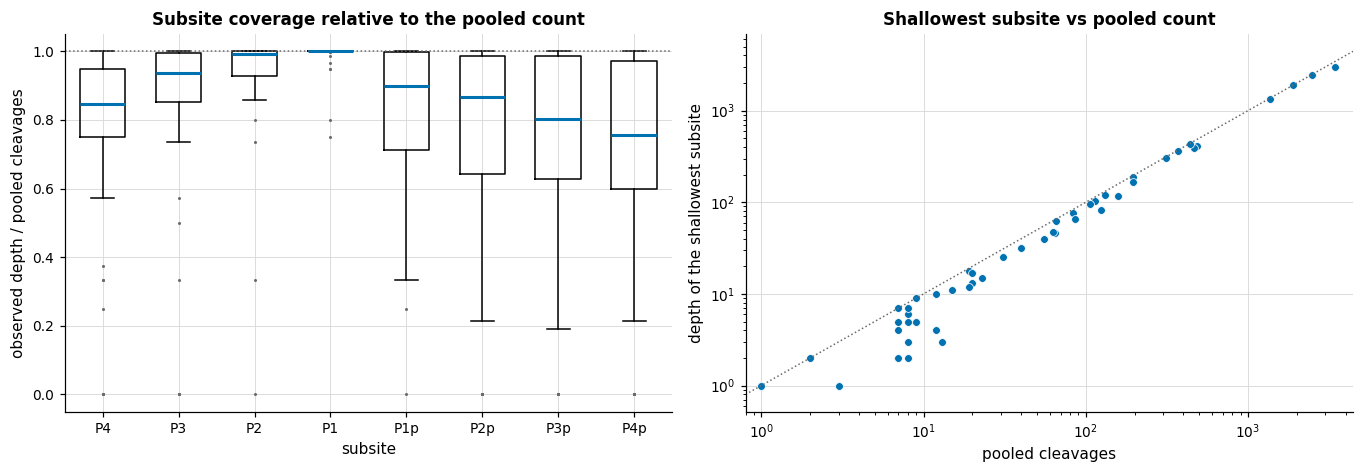

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
positions = np.arange(len(MEROPS_SUBSITES))
ax.boxplot(
    [relative_depth[:, i] for i in positions],
    positions=positions,
    widths=0.6,
    medianprops={"color": common.CATEGORICAL_COLORS[0], "linewidth": 2},
    flierprops={"marker": ".", "markersize": 4, "markerfacecolor": common.NEUTRAL, "markeredgecolor": "none"},
)
ax.set_xticks(positions)
ax.set_xticklabels(MEROPS_SUBSITES)
ax.set_ylabel("observed depth / pooled cleavages")
ax.set_xlabel("subsite")
ax.set_title("Subsite coverage relative to the pooled count")
ax.axhline(1.0, color=common.NEUTRAL, linewidth=1.0, linestyle=":")

ax = axes[1]
ax.scatter(
    depth_frame["n_cleavages"],
    depth_frame["min_subsite_depth"],
    s=26,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="white",
    linewidth=0.5,
)
limits = [0.8, max(depth_frame["n_cleavages"].max(), 1) * 1.3]
ax.plot(limits, limits, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(*limits)
ax.set_xlabel("pooled cleavages")
ax.set_ylabel("depth of the shallowest subsite")
ax.set_title("Shallowest subsite vs pooled count")
fig.tight_layout()
plt.show()

## Divergence of each subsite from the substrate composition

### Definition

For a subsite with smoothed residue distribution $p$ and reference
distribution $q$, the metric is the Kullback-Leibler divergence in bits,

$$\mathrm{IC}(p \| q) = \sum_a p_a \log_2 \frac{p_a}{q_a}.$$

### Choice of the reference distribution

$q$ defines what the subsite is compared against. The classical sequence-logo
form $\log_2 20 - H(p)$ is the special case $q_a = 1/20$, which asserts that
every residue is equally likely to occupy a subsite. No proteome satisfies
this: in the human reference proteome leucine is 8.2 times more frequent than
tryptophan. Under a uniform reference a subsite that only reproduces the
composition of the substrate pool is reported as specific, and every reported
value carries a constant offset of $D_{\mathrm{KL}}(q_{\text{human}} \| u) =
0.145$ bits.

The reference used here is the residue composition of the reviewed human
reference proteome (UniProt UP000005640, 20 416 sequences, 11.4 million
residues). MEROPS substrates are predominantly human or human-derived
sequences, so this is the composition a subsite shows in the absence of any
preference.

### Sampling floor

A subsite observed a few times departs from $q$ even when its residues were
drawn from $q$, because a small multinomial sample cannot reproduce a
20-residue distribution. The floor is estimated by Monte Carlo: residues are
drawn from $q$ at the observed depth and scored against the same $q$.

### Limitations

The floor is not monotone in depth. The Jeffreys prior of the distributed
matrices pulls a very small sample towards a uniform distribution, so the
excess over the floor is not comparable across widely different sample sizes,
and `n_cleavages` remains the gate at the bottom of the panel.

The smoothing prior is left unchanged. It is the prior that produced the
distributed `matrices_logprob.npy`, and the audit measures the matrix the model
consumes rather than a differently estimated one.

In [9]:
observed_ic, null_ic, excess_ic = information_content_excess(
    counts, n_samples=600, seed=SEED, background=human_background
)

ic_frame = pd.DataFrame(
    {
        "code": codes,
        "n_cleavages": panel["n_cleavages"].to_numpy(),
        "mean_divergence": observed_ic.mean(axis=1),
        "mean_null_divergence": null_ic.mean(axis=1),
        "mean_divergence_excess": excess_ic.mean(axis=1),
        "max_divergence_excess": excess_ic.max(axis=1),
    }
)
print(ic_frame.sort_values("mean_divergence_excess", ascending=False).head(10).round(3).to_string(index=False))
print()
print(
    f"peptidases whose mean divergence does not exceed the sampling floor: "
    f"{int((ic_frame['mean_divergence_excess'] <= 0).sum())} / {len(ic_frame)}"
)

   code  n_cleavages  mean_divergence  mean_null_divergence  mean_divergence_excess  max_divergence_excess
S01.216           63            0.877                 0.186                   0.690                  2.477
S01.217          195            0.738                 0.071                   0.667                  3.024
S01.010         1902            0.651                 0.007                   0.644                  2.818
S01.133          465            0.620                 0.030                   0.590                  1.503
M10.013          158            0.662                 0.084                   0.577                  1.470
S01.135          441            0.597                 0.030                   0.567                  2.208
S01.161           66            0.698                 0.164                   0.534                  2.394
S01.212           40            0.761                 0.237                   0.524                  1.857
S01.140          107            0.628

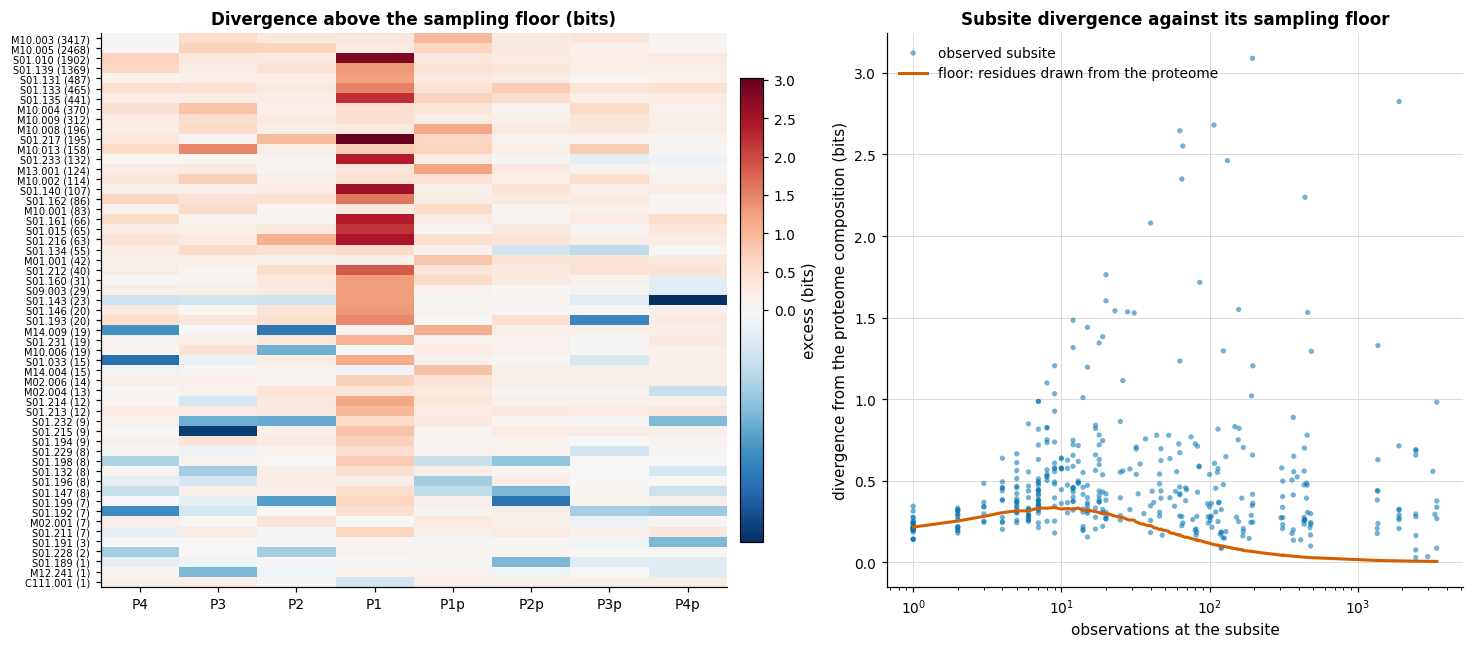

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 6.0), gridspec_kw={"width_ratios": [1.15, 1]})

## Diverging map: zero excess is the neutral midpoint
ax = axes[0]
order = np.argsort(-panel["n_cleavages"].to_numpy())
### REMARK: The excess is one-sided in practice (a handful of slightly negative
### cells against a long positive tail), so the diverging ramp is anchored at
### zero with TwoSlopeNorm instead of symmetric limits, which would spend half
### the ramp on an empty range and flatten the real differences.
image = ax.imshow(
    excess_ic[order],
    aspect="auto",
    cmap=common.DIVERGING_CMAP,
    norm=TwoSlopeNorm(
        vmin=min(float(excess_ic.min()), -0.05),
        vcenter=0.0,
        vmax=float(excess_ic.max()),
    ),
    interpolation="nearest",
)
ax.set_xticks(range(len(MEROPS_SUBSITES)))
ax.set_xticklabels(MEROPS_SUBSITES)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f"{codes[i]} ({int(panel['n_cleavages'][i])})" for i in order], fontsize=6.5)
ax.set_title("Divergence above the sampling floor (bits)")
ax.grid(visible=False)
fig.colorbar(image, ax=ax, fraction=0.035, pad=0.02, label="excess (bits)")

## Observed vs floor as a function of depth
ax = axes[1]
depth_grid = np.unique(np.clip(subsite_depth.astype(int), 1, None))
null_curve = expected_null_information_content(
    depth_grid, n_samples=600, seed=SEED, background=human_background
)
ax.scatter(
    subsite_depth.ravel(),
    observed_ic.ravel(),
    s=12,
    color=common.CATEGORICAL_COLORS[0],
    alpha=0.55,
    edgecolor="none",
    label="observed subsite",
)
ax.plot(depth_grid, null_curve, color=common.CATEGORICAL_COLORS[1], linewidth=2, label="floor: residues drawn from the proteome")
ax.set_xscale("log")
ax.set_xlabel("observations at the subsite")
ax.set_ylabel("divergence from the proteome composition (bits)")
ax.set_title("Subsite divergence against its sampling floor")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

## Reproducibility of the per-protease score

### Procedure

Each subsite is resampled from its own multinomial at its observed depth, the
matrices are rebuilt with the same Jeffreys prior, and every replicate re-ranks
the same peptide probe. The reported statistic is the Spearman correlation
between the ranking of a replicate and the ranking produced by the distributed
matrix.

### Interpretation

The quantity that enters the objective is the ranking the matrix produces, not
the appearance of the matrix. A protease whose ranking is preserved under
resampling contributes a reproducible score; a protease whose ranking is not
preserved contributes noise at the same nominal score magnitude.

### Probe

A fixed random sample of DBAASP sequences, which is the peptide space the
matrices are applied to in the downstream objective.

### Limitation

MEROPS distributes pooled per-subsite counts rather than individual cleavage
records, so subsites are resampled independently. This matches the
independence assumption the matrices already encode and cannot reproduce
correlations between neighbouring subsites of one cleavage.

In [11]:
probe = (
    pd.read_csv(common.PEPTIDES_APEX_CSV, usecols=["sequence", "dataset"])
    .query("dataset.str.contains('dbaasp', case=False, na=False)")
    .drop_duplicates(subset=["sequence"])
    .sample(n=N_PROBE_PEPTIDES, random_state=SEED)
    .reset_index(drop=True)
)
probe_sequences = probe["sequence"].tolist()
print(f"probe peptides: {len(probe_sequences)} | length {probe['sequence'].str.len().min()}"
      f"-{probe['sequence'].str.len().max()}")

reference_potential = CleavagePotential(logprob_panel, variant="product", device=DEVICE)
reference_rates, _ = reference_potential.sequence_protease_rates(probe_sequences)  # (n_probe, N)
print(f"reference per-protease rates: {reference_rates.shape}")

probe peptides: 1000 | length 10-25


reference per-protease rates: (1000, 55)


In [12]:
## Propagate count uncertainty into the per-protease ranking of the probe
replicate_matrices = bootstrap_specificity_matrices(counts, n_replicates=N_BOOTSTRAP, seed=SEED)  # (B, N, P, A)
stability = np.zeros((N_BOOTSTRAP, len(codes)))

for replicate in range(N_BOOTSTRAP):
    replicate_panel = ProteasePanel(
        matrices=torch.as_tensor(replicate_matrices[replicate], dtype=torch.float32, device=DEVICE),
        weights=logprob_panel.weights,
        codes=codes,
    )
    replicate_rates, _ = CleavagePotential(
        replicate_panel, variant="product", device=DEVICE
    ).sequence_protease_rates(probe_sequences)  # (n_probe, N)
    for protease in range(len(codes)):
        correlation = spearmanr(reference_rates[:, protease], replicate_rates[:, protease]).statistic
        stability[replicate, protease] = 0.0 if np.isnan(correlation) else correlation

stability_frame = pd.DataFrame(
    {
        "code": codes,
        "n_cleavages": panel["n_cleavages"].to_numpy(),
        "median_rank_stability": np.median(stability, axis=0),
        "p10_rank_stability": np.percentile(stability, 10, axis=0),
    }
)
print(stability_frame.sort_values("median_rank_stability").head(12).round(3).to_string(index=False))

   code  n_cleavages  median_rank_stability  p10_rank_stability
S01.191            3                  0.311               0.126
S01.199            7                  0.360               0.219
S01.228            2                  0.373               0.133
S01.192            7                  0.386               0.202
S01.229            8                  0.441               0.214
S01.132            8                  0.479               0.252
S01.189            1                  0.482               0.233
S01.232            9                  0.491               0.269
S01.196            8                  0.491               0.184
S01.211            7                  0.497               0.321
S01.198            8                  0.502               0.245
S01.215            9                  0.524               0.306


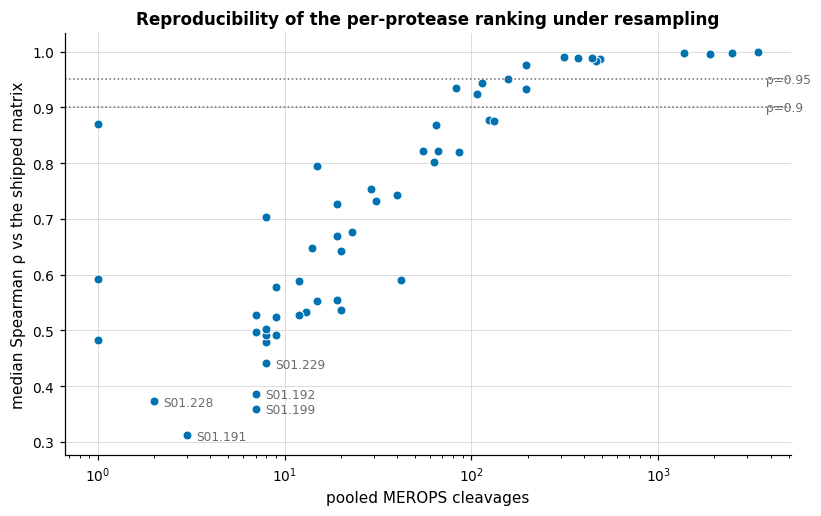

In [13]:
fig, ax = plt.subplots(figsize=(7.6, 4.8))
ax.scatter(
    stability_frame["n_cleavages"],
    stability_frame["median_rank_stability"],
    s=34,
    color=common.CATEGORICAL_COLORS[0],
    edgecolor="white",
    linewidth=0.6,
)
for _, row in stability_frame.nsmallest(5, "median_rank_stability").iterrows():
    ax.annotate(
        row["code"],
        (row["n_cleavages"], row["median_rank_stability"]),
        textcoords="offset points",
        xytext=(6, -3),
        fontsize=8,
        color=common.NEUTRAL,
    )
for threshold in (0.9, 0.95):
    ax.axhline(threshold, color=common.NEUTRAL, linestyle=":", linewidth=1.0)
    ax.text(ax.get_xlim()[1], threshold, f" ρ={threshold}", va="center", fontsize=8, color=common.NEUTRAL)
ax.set_xscale("log")
ax.set_xlabel("pooled MEROPS cleavages")
ax.set_ylabel("median Spearman ρ vs the shipped matrix")
ax.set_title("Reproducibility of the per-protease ranking under resampling")
fig.tight_layout()
plt.show()

## Number of distinct specificity profiles

The `reduction="sum"` aggregation of `CleavagePotential` adds a contribution
from every panel entry, so entries encoding the same preference enter the sum
several times.

Redundancy is measured in two spaces. Matrix space uses the correlation of the
log-odds profiles against the reference distribution. Score space uses the
correlation of the per-protease scores across the probe peptides. Score space
determines the ranking the objective produces.

In [14]:
matrix_similarity = profile_similarity_matrix(log_probabilities, background=human_background)  # (N, N)
with np.errstate(invalid="ignore"):
    score_similarity = np.corrcoef(np.log1p(np.maximum(reference_rates, 0.0)).T)  # (N, N)
score_similarity = np.nan_to_num(score_similarity, nan=0.0)

matrix_labels = cluster_profiles(matrix_similarity, threshold=REDUNDANCY_THRESHOLD)
score_labels = cluster_profiles(score_similarity, threshold=REDUNDANCY_THRESHOLD)
print(
    f"distinct profiles at r >= {REDUNDANCY_THRESHOLD}: "
    f"{len(np.unique(matrix_labels))} (matrix space), "
    f"{len(np.unique(score_labels))} (score space), out of {len(codes)} entries"
)

redundant_groups = (
    pd.DataFrame({"code": codes, "cluster": score_labels})
    .groupby("cluster")["code"]
    .apply(list)
)
for cluster, members in redundant_groups.items():
    if len(members) > 1:
        print(f"  score-space cluster {cluster}: {', '.join(members)}")

distinct profiles at r >= 0.8: 51 (matrix space), 53 (score space), out of 55 entries
  score-space cluster 45: M10.002, M10.004, M10.013


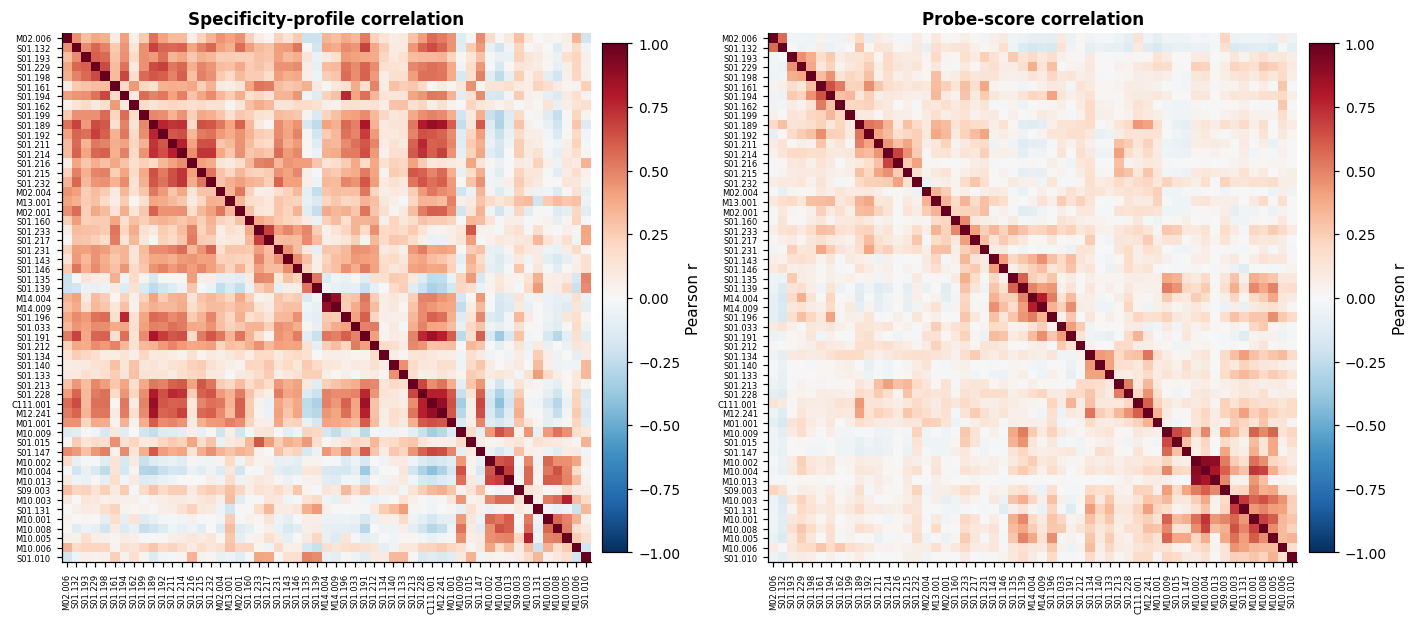

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.0))
cluster_order = np.argsort(score_labels, kind="stable")
for ax, similarity, title in [
    (axes[0], matrix_similarity, "Specificity-profile correlation"),
    (axes[1], score_similarity, "Probe-score correlation"),
]:
    image = ax.imshow(
        similarity[np.ix_(cluster_order, cluster_order)],
        cmap=common.DIVERGING_CMAP,
        vmin=-1,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_xticks(range(len(codes)))
    ax.set_xticklabels([codes[i] for i in cluster_order], rotation=90, fontsize=5.5)
    ax.set_yticks(range(len(codes)))
    ax.set_yticklabels([codes[i] for i in cluster_order], fontsize=5.5)
    ax.set_title(title)
    ax.grid(visible=False)
    fig.colorbar(image, ax=ax, fraction=0.045, pad=0.02, label="Pearson r")
fig.tight_layout()
plt.show()

## Audit table

One row per panel entry with its evidence depth, divergence excess, score
reproducibility and redundancy group. The `merops_matrix_verdict` column
combines the cleavage count with the score reproducibility and is consumed by
`0_14_dataset_definition.ipynb`.

In [16]:
audit = (
    panel[["code", "name", "serum_category", "n_cleavages"]]
    .merge(depth_frame[["code", "min_subsite_depth", "median_subsite_depth"]], on="code")
    .merge(
        ic_frame[["code", "mean_divergence", "mean_null_divergence", "mean_divergence_excess"]],
        on="code",
    )
    .merge(stability_frame[["code", "median_rank_stability", "p10_rank_stability"]], on="code")
)
audit["matrix_cluster"] = matrix_labels
audit["score_cluster"] = score_labels
audit["score_cluster_size"] = audit["score_cluster"].map(audit["score_cluster"].value_counts())

## Coarse verdict on whether the matrix can be scored at all
audit["merops_matrix_verdict"] = np.select(
    [
        (audit["n_cleavages"] >= 100) & (audit["median_rank_stability"] >= 0.95),
        (audit["n_cleavages"] >= 20) & (audit["median_rank_stability"] >= 0.90),
        audit["n_cleavages"] >= 5,
    ],
    ["well_determined", "usable", "weak"],
    default="uninformative",
)
print(audit["merops_matrix_verdict"].value_counts().to_string())

destination = common.save_result(audit.round(4), "0_01_merops_matrices.csv")
print(f"\nwritten: {destination.relative_to(common.ROOT)}")
audit.sort_values("n_cleavages", ascending=False).head(15).round(3)

merops_matrix_verdict
weak               35
well_determined    11
uninformative       5
usable              4

written: assets/experiments/analysis/09_26/20_serum_proteolysis_calibration_max/results/0_01_merops_matrices.csv


,code,name,serum_category,n_cleavages,min_subsite_depth,median_subsite_depth,mean_divergence,mean_null_divergence,mean_divergence_excess,median_rank_stability,p10_rank_stability,matrix_cluster,score_cluster,score_cluster_size,merops_matrix_verdict
7,M10.003,matrix metallopeptidase-2,metalloproteases_plasma,3417,2966.0,3409.5,0.366,0.004,0.362,0.999,0.998,1,47,1,well_determined
9,M10.005,matrix metallopeptidase-3,metalloproteases_plasma,2468,2463.0,2466.0,0.359,0.006,0.353,0.997,0.997,2,51,1,well_determined
18,S01.010,granzyme B ({Homo sapiens}-type),neutrophil_and_leukocyte_serine,1902,1896.0,1900.0,0.651,0.007,0.644,0.996,0.995,21,53,1,well_determined
26,S01.139,granzyme M,neutrophil_and_leukocyte_serine,1369,1354.0,1360.5,0.479,0.010,0.469,0.997,0.996,20,27,1,well_determined
21,S01.131,elastase-2,neutrophil_and_leukocyte_serine,487,412.0,481.0,0.335,0.028,0.307,0.986,0.980,22,48,1,well_determined
23,S01.133,cathepsin G,neutrophil_and_leukocyte_serine,465,390.0,453.0,0.620,0.030,0.590,0.983,0.979,17,36,1,well_determined
25,S01.135,granzyme A,neutrophil_and_leukocyte_serine,441,433.0,436.0,0.597,0.030,0.567,0.988,0.984,19,26,1,well_determined
8,M10.004,matrix metallopeptidase-9,metalloproteases_plasma,370,360.0,367.0,0.439,0.036,0.403,0.988,0.984,3,45,3,well_determined
12,M10.009,matrix metallopeptidase-12,metalloproteases_plasma,312,303.0,311.0,0.349,0.042,0.307,0.990,0.985,8,42,1,well_determined
11,M10.008,matrix metallopeptidase-7,metalloproteases_plasma,196,190.0,195.0,0.470,0.065,0.405,0.975,0.967,7,50,1,well_determined
